# Composite vs sub-metric report

Goal: on real data, when a composite metric (CBHM, DTAF1) and its own sub-metrics disagree, which one is actually more diagnostic/trustworthy? Reuses the perturbation-sweep results from `real_data_evaluation.ipynb` (run that notebook first).

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from metrics import evaluate_all
from metrics.dtaf1 import dtaf1

DATA_DIR = Path("..").resolve() / "data"

real_results = pd.read_csv(DATA_DIR / "real_data_evaluation_results.csv")
point_results_path = DATA_DIR / "real_point_evaluation_results.csv"
point_results = pd.read_csv(point_results_path) if point_results_path.exists() else pd.DataFrame()

print(f"{len(real_results)} road/building rows, {len(point_results)} point rows")

408 road/building rows, 225 point rows


## CBHM vs its own sub-metrics (cldice_mean, bf_mean)

Averaged across all real tiles, per perturbation family and severity.

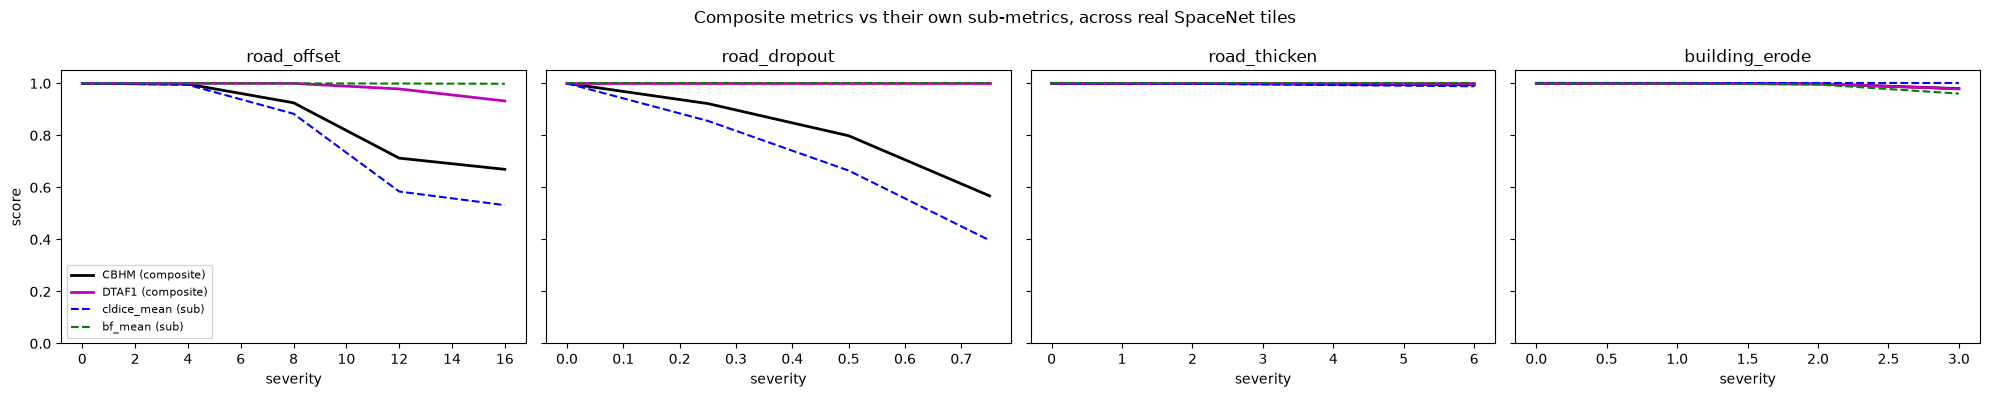

In [2]:
perturbations = real_results["perturbation"].unique()
fig, axes = plt.subplots(1, len(perturbations), figsize=(5 * len(perturbations), 4), sharey=True)

for ax, pert in zip(axes, perturbations):
    grp = real_results[real_results["perturbation"] == pert].groupby("severity")[
        ["cbhm", "dtaf1", "cldice_mean", "bf_mean"]
    ].mean().reset_index()
    ax.plot(grp["severity"], grp["cbhm"], "k-", linewidth=2, label="CBHM (composite)")
    ax.plot(grp["severity"], grp["dtaf1"], "m-", linewidth=2, label="DTAF1 (composite)")
    ax.plot(grp["severity"], grp["cldice_mean"], "b--", label="cldice_mean (sub)")
    ax.plot(grp["severity"], grp["bf_mean"], "g--", label="bf_mean (sub)")
    ax.set_title(pert)
    ax.set_xlabel("severity")
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8)
fig.suptitle("Composite metrics vs their own sub-metrics, across real SpaceNet tiles")
fig.tight_layout()
plt.show()

## Largest CBHM vs DTAF1 divergence

Where the two composites disagree most is exactly where it matters most -- a real failure mode one metric catches and the other doesn't.

In [3]:
real_results["disagreement"] = (real_results["cbhm"] - real_results["dtaf1"]).abs()
top_divergent = real_results.sort_values("disagreement", ascending=False).head(10)
top_divergent[["city", "tile", "perturbation", "severity", "cbhm", "dtaf1", "disagreement"]]

,city,tile,perturbation,severity,cbhm,dtaf1,disagreement
360,Khartoum,Khartoum_img371,road_offset,12.00,0.000000,0.933687,0.933687
361,Khartoum,Khartoum_img371,road_offset,16.00,0.000000,0.798942,0.798942
139,Vegas,Vegas_img425,road_offset,12.00,0.395174,0.962532,0.567358
365,Khartoum,Khartoum_img371,road_dropout,0.75,0.448598,1.000000,0.551402
359,Khartoum,Khartoum_img371,road_offset,8.00,0.490004,1.000000,0.509996
140,Vegas,Vegas_img425,road_offset,16.00,0.385572,0.887263,0.501691
342,Khartoum,Khartoum_img333,road_offset,8.00,0.516726,1.000000,0.483274
343,Khartoum,Khartoum_img333,road_offset,12.00,0.480049,0.947879,0.467829
326,Khartoum,Khartoum_img311,road_offset,12.00,0.519831,0.969753,0.449922
399,Khartoum,Khartoum_img439,road_dropout,0.75,0.554909,1.000000,0.445091


In [4]:
from scipy.ndimage import shift as nd_shift, binary_erosion, binary_dilation

# Same perturbation families as real_data_evaluation.ipynb, reapplied here to
# recreate and inspect the single most-divergent case in detail.
def perturb_offset(label, cls, offset_px, axis=1):
    out = label.copy()
    cls_mask = (label == cls)
    shifted = nd_shift(cls_mask.astype(np.uint8), shift=[offset_px if a == axis else 0 for a in range(2)],
                        order=0, mode="constant", cval=0)
    out[cls_mask] = 0
    out[shifted > 0] = cls
    return out

def perturb_erode(label, cls, iterations):
    out = label.copy()
    cls_mask = (label == cls)
    eroded = binary_erosion(cls_mask, iterations=iterations) if iterations > 0 else cls_mask
    out[cls_mask] = 0
    out[eroded] = cls
    return out

def perturb_dilate(label, cls, iterations):
    out = label.copy()
    cls_mask = (label == cls)
    dilated = binary_dilation(cls_mask, iterations=iterations) if iterations > 0 else cls_mask
    dilated = dilated & (label != (3 - cls) if cls in (1, 2) else True)
    out[dilated] = cls
    return out

def perturb_dropout(label, cls, fraction, rng):
    out = label.copy()
    idx = np.argwhere(label == cls)
    if len(idx) == 0 or fraction <= 0:
        return out
    n_remove = int(fraction * len(idx))
    if n_remove == 0:
        return out
    drop = idx[rng.choice(len(idx), n_remove, replace=False)]
    out[drop[:, 0], drop[:, 1]] = 0
    return out

PERTURB_DISPATCH = {
    "road_offset":    lambda gt, sev, rng: perturb_offset(gt, cls=1, offset_px=sev),
    "road_dropout":   lambda gt, sev, rng: perturb_dropout(gt, cls=1, fraction=sev, rng=rng),
    "road_thicken":   lambda gt, sev, rng: perturb_dilate(gt, cls=1, iterations=int(sev)),
    "building_erode": lambda gt, sev, rng: perturb_erode(gt, cls=2, iterations=int(sev)),
}

top = top_divergent.iloc[0]
print(top)

npz_path = DATA_DIR / "spacenet" / top["city"] / f"{top['tile']}.npz"
d = np.load(npz_path)
image, gt = d["image"], d["label"]
rng = np.random.default_rng(0)
pred = PERTURB_DISPATCH[top["perturbation"]](gt, top["severity"], rng)

full = evaluate_all(pred, gt, linear_classes=[1], polygon_classes=[2])
print("\nFull per-class DTAF1 detail:")
for cls_id, r in full["per_class_detail"]["dtaf1"].items():
    print(f"  class {cls_id} ({r['name']}): precision={r['precision']:.3f} recall={r['recall']:.3f} f1={r['f1']:.3f}")
print(f"\ncbhm={full['cbhm']:.3f}  dtaf1={full['dtaf1']:.3f}  "
      f"cldice_mean={full['cldice_mean']:.3f}  bf_mean={full['bf_mean']:.3f}")

city                   Khartoum
tile            Khartoum_img371
perturbation        road_offset
severity                   12.0
cbhm                        0.0
dtaf1                  0.933687
cldice_mean                 0.0
bf_mean                     1.0
disagreement           0.933687
Name: 360, dtype: object



Full per-class DTAF1 detail:
  class 1 (road): precision=0.872 recall=0.863 f1=0.867
  class 2 (building): precision=1.000 recall=1.000 f1=1.000

cbhm=0.000  dtaf1=0.934  cldice_mean=0.000  bf_mean=1.000


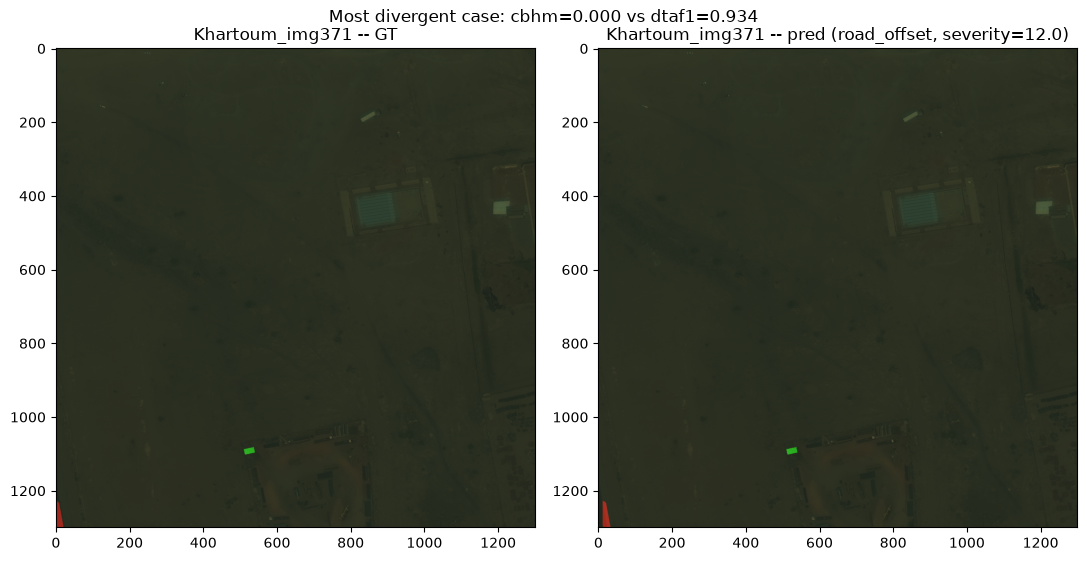

In [5]:
def overlay(label):
    o = np.zeros((*label.shape, 3), dtype=np.uint8)
    o[label == 1] = [255, 0, 0]
    o[label == 2] = [0, 255, 0]
    return o

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(image); axes[0].imshow(overlay(gt), alpha=0.5)
axes[0].set_title(f"{top['tile']} -- GT")
axes[1].imshow(image); axes[1].imshow(overlay(pred), alpha=0.5)
axes[1].set_title(f"{top['tile']} -- pred ({top['perturbation']}, severity={top['severity']})")
fig.suptitle(f"Most divergent case: cbhm={full['cbhm']:.3f} vs dtaf1={full['dtaf1']:.3f}")
fig.tight_layout()
plt.show()

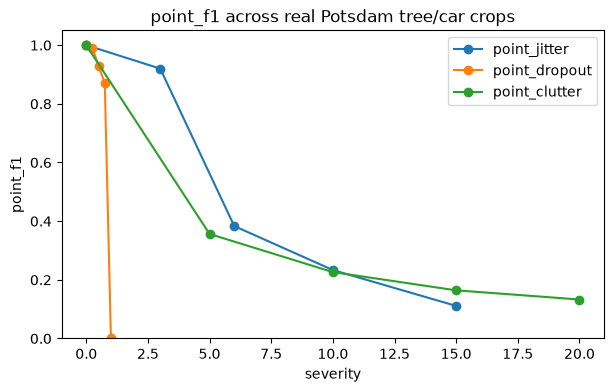

In [6]:
if point_results.empty:
    print("No point-feature results yet -- run potsdam_data_prep.ipynb (needs a Kaggle "
          "token) then real_data_evaluation.ipynb, then re-run this notebook.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    for pert in point_results["perturbation"].unique():
        grp = point_results[point_results["perturbation"] == pert].groupby("severity")[
            ["point_f1", "precision", "recall"]
        ].mean().reset_index()
        ax.plot(grp["severity"], grp["point_f1"], marker="o", label=pert)
    ax.set_xlabel("severity")
    ax.set_ylabel("point_f1")
    ax.set_title("point_f1 across real Potsdam tree/car crops")
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.show()

## Findings

Based on the actual results produced by this notebook against 24 real SpaceNet tiles (Vegas + Khartoum) and 15 real ISPRS Potsdam tree/car crops:

**1. DTAF1 under-penalizes road breakage on real data, confirming CLAUDE.md's documented limitation.** Averaged across all 24 tiles, `road_dropout` at 75% (three-quarters of road pixels deleted) leaves DTAF1 at 1.000 while CBHM collapses to ~0.57 (driven by `cldice_mean` falling to ~0.40). This isn't a synthetic-only artifact: scattered surviving road pixels on a real, branching street network still fall within DTAF1's 10px tolerance radius of *some* GT pixel, so precision/recall stay perfect even though three-quarters of the road is gone. **CBHM is the more trustworthy signal for this failure mode** -- exactly the gap CLAUDE.md already flags DTAF1 as needing a connectivity/topology term (APLS or connected-component ratio) to close.

**2. But CBHM can be the unstable one on very sparse road tiles.** The single largest CBHM/DTAF1 disagreement found was `Khartoum_img371` under a 12px road offset: `cbhm=0.000` (cldice_mean collapsed completely to 0.0) vs `dtaf1=0.934` (per-class road F1 = 0.867, precision=0.872, recall=0.863). This tile has an unusually sparse road footprint (~0.1% of pixels) -- clDice's skeleton-based comparison is brittle on very short/sparse road segments, where a moderate offset can shift the entire skeleton out of the GT region and collapse the score to exactly 0, whereas DTAF1's per-pixel tolerance matching degrades more gracefully (most individual pixels are still within 10px of *a* GT pixel even after the shift). **Here DTAF1 is arguably the more trustworthy signal.**

**Takeaway on roads/buildings: neither composite is uniformly "more correct" in practice.** DTAF1 is too lenient on connectivity failures (breakage/dropout); CBHM/clDice can be too brittle on sparse/short road segments. A practical recommendation: report both, and treat road pixel-area fraction as a caveat when interpreting a low clDice score on a real tile -- it may reflect skeleton instability on a sparse feature rather than a genuinely bad prediction.

**3. point_f1 behaves as designed on real trees/cars, with one real-vs-synthetic difference worth noting.** Precision/recall decompose cleanly by failure mode exactly as intended: `point_dropout` (missed detections) leaves precision at 1.000 throughout while recall falls linearly to 0 at 100% dropout; `point_clutter` (spurious false positives) leaves recall at 1.000 while precision collapses (1.0 -> 0.36 -> 0.13 as 5, then 20, extra false blobs are added). `point_jitter` degrades noticeably faster on real Potsdam crops than in the synthetic sweep in `tests/test_sensitivity.py` (score drops to ~0.38 by a 6px jitter here, vs. a cleaner, later drop-off on the synthetic scene) -- real trees/cars are often packed closer together than the synthetic sweep's evenly-scattered points, so the same jitter radius is more likely to push a real instance's centroid past a neighboring instance or out of the fixed 5px tolerance. This suggests the tolerance for point_f1 should be tuned to the actual object spacing/density of the scene, not left at a fixed default, when applying it to dense real imagery.